In [1]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

available = {font.name for font in font_manager.fontManager.ttflist}
for family in ["Leelawadee UI", "Tahoma", "Arial", "Angsana New", "Microsoft Sans Serif", "DejaVu Sans"]:
    if family in available:
        plt.rcParams["font.family"] = family
        break

plt.rcParams["axes.unicode_minus"] = False
print("Thai-capable font set:", plt.rcParams["font.family"])

ModuleNotFoundError: No module named 'matplotlib'


# Lab 4 — Grab & Passenger
## อธิบาย Q1 Brute Force + Q2 Greedy แบบทีละส่วน

Notebook นี้แยกโค้ดออกเป็นเซลเล็ก ๆ เพื่อให้เห็นว่าแต่ละส่วนทำอะไร

### สัญลักษณ์
- `G` = Grab
- `P` = Passenger
- `k` = ระยะไกลที่สุดที่ Grab สามารถรับ Passenger ได้
- Grab 1 คันรับ Passenger ได้ 1 คน
- Passenger 1 คนใช้ได้เพียง 1 ครั้ง

เราจะใช้ตัวอย่างหลัก:

```text
GPPGP
k = 1

index : 0 1 2 3 4
        G P P G P
```

> แนะนำ: รันทีละเซลจากบนลงล่าง แล้วดูค่าที่ได้ในแต่ละขั้น



# ส่วนที่ 0 — เตรียมข้อมูลตัวอย่าง

ในไฟล์ `.py` จริงของเราใช้ `input()` แต่ตอนเรียนใน Notebook จะกำหนดค่าไว้ก่อน  
เพื่อให้กด Run ได้ง่ายและเห็นผลทันที


In [ ]:

s = "GPPGP"
k = 1

print("ข้อมูล =", s)
print("k =", k)


ข้อมูล = GPPGP
k = 1



## แยกตำแหน่ง Grab และ Passenger

เราไม่จำเป็นต้องเก็บตัวอักษรทั้งหมดตลอดเวลา  
สิ่งที่สำคัญคือ **ตำแหน่ง index**

จาก

```text
G P P G P
0 1 2 3 4
```

ควรได้

```python
grabs = [0, 3]
passengers = [1, 2, 4]
```


In [ ]:

grabs = []
passengers = []

for i in range(len(s)):
    if s[i] == 'G':
        grabs.append(i)
    elif s[i] == 'P':
        passengers.append(i)

print("grabs      =", grabs)
print("passengers =", passengers)


grabs      = [0, 3]
passengers = [1, 2, 4]



## ภาพตำแหน่ง G และ P

ภาพนี้ช่วยให้เห็นว่าแต่ละตัวอยู่ที่ index ไหน


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, 

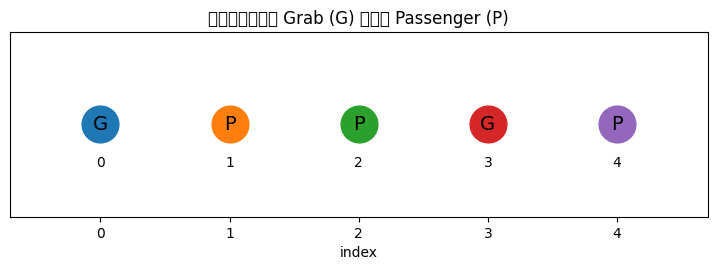

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 2.4))

for i, ch in enumerate(s):
    plt.scatter(i, 0, s=700)
    plt.text(i, 0, ch, ha="center", va="center", fontsize=14)
    plt.text(i, -0.23, str(i), ha="center", va="center", fontsize=10)

plt.xlim(-0.7, len(s)-0.3)
plt.ylim(-0.55, 0.55)
plt.yticks([])
plt.xlabel("index")
plt.title("ตำแหน่ง Grab (G) และ Passenger (P)")
plt.show()



# Q1 — Brute Force + Backtracking

## แนวคิดหลัก

Brute Force คือ **ลองทุกทางเลือก**

เมื่อเรากำลังพิจารณา Grab 1 คัน เรามีทางเลือก เช่น

```text
Grab คันนี้
├── ไม่รับ Passenger
├── รับ Passenger คนที่ 1 (ถ้าอยู่ในระยะ)
├── รับ Passenger คนที่ 2 (ถ้าอยู่ในระยะ)
└── ...
```

แล้วทำแบบเดียวกันกับ Grab คันถัดไป

สิ่งสำคัญคือ Passenger ที่ถูกใช้แล้ว **ห้ามถูกใช้ซ้ำ**



## Q1.1 ตัวแปรที่ใช้จำสถานะ

```python
used = set()
```

ใช้เก็บ Passenger ที่มี Grab รับไปแล้ว

เช่น

```python
used = {1}
```

หมายความว่า Passenger ที่ index `1` ถูกใช้ไปแล้ว

ส่วน

```python
max_passengers
```

เก็บจำนวน Passenger สูงสุดที่เคยเจอ

และ

```python
num_solutions
```

เก็บจำนวนวิธีที่ทำให้ได้ค่าสูงสุดนั้น


In [ ]:

used = set()

max_passengers = 0
num_solutions = 0

print("used =", used)
print("max_passengers =", max_passengers)
print("num_solutions =", num_solutions)


used = set()
max_passengers = 0
num_solutions = 0



## Q1.2 ภาพแนวคิด Recursion

สำหรับ `GPPGP, k = 1`

- Grab index 0 รับ Passenger index 1 ได้
- Grab index 3 รับ Passenger index 2 หรือ 4 ได้

จึงเกิดการแตกแขนงของทางเลือก


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

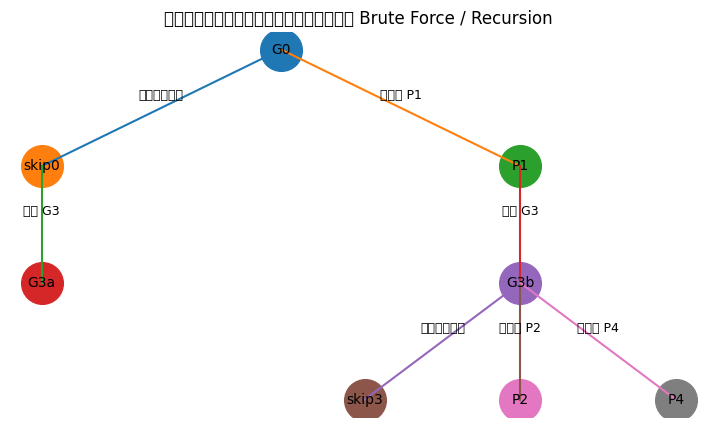

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

nodes = {
    "G0": (0, 4),
    "skip0": (-2, 3),
    "P1": (2, 3),
    "G3a": (-2, 2),
    "G3b": (2, 2),
    "skip3": (0.7, 1),
    "P2": (2, 1),
    "P4": (3.3, 1),
}

edges = [
    ("G0", "skip0", "ไม่รับ"),
    ("G0", "P1", "รับ P1"),
    ("skip0", "G3a", "ไป G3"),
    ("P1", "G3b", "ไป G3"),
    ("G3b", "skip3", "ไม่รับ"),
    ("G3b", "P2", "รับ P2"),
    ("G3b", "P4", "รับ P4"),
]

for a, b, label in edges:
    x1, y1 = nodes[a]
    x2, y2 = nodes[b]
    plt.plot([x1, x2], [y1, y2])
    plt.text((x1+x2)/2, (y1+y2)/2 + 0.08, label, ha="center", fontsize=9)

for name, (x, y) in nodes.items():
    plt.scatter(x, y, s=900)
    plt.text(x, y, name, ha="center", va="center", fontsize=10)

plt.axis("off")
plt.title("แนวคิดการแตกแขนงของ Brute Force / Recursion")
plt.show()



## Q1.3 ฟังก์ชัน `search(index, count)`

ความหมายของ parameter:

- `index` = ตอนนี้กำลังพิจารณา Grab ตัวที่เท่าไรใน `grabs`
- `count` = ตอนนี้จับ Passenger ได้แล้วกี่คน

ตัวอย่าง

```python
search(0, 0)
```

แปลว่า

> เริ่มที่ Grab ตัวแรก และตอนนี้ยังจับ Passenger ได้ 0 คน


In [ ]:

def search(index, count):
    global max_passengers
    global num_solutions

    # Base Case:
    # ถ้าพิจารณา Grab ครบทุกคันแล้ว ให้ตรวจคำตอบ
    if index == len(grabs):

        if count > max_passengers:
            max_passengers = count
            num_solutions = 1

        elif count == max_passengers:
            num_solutions += 1

        return

    # ทางเลือกที่ 1:
    # Grab คันนี้ไม่รับ Passenger
    search(index + 1, count)

    # ทางเลือกที่ 2:
    # ลอง Passenger ทุกคน
    for p in passengers:

        # ต้องยังไม่ถูกใช้ และอยู่ห่างไม่เกิน k
        if p not in used and abs(grabs[index] - p) <= k:

            # 1) เลือก
            used.add(p)

            # 2) ไปลอง Grab ตัวถัดไป
            search(index + 1, count + 1)

            # 3) ย้อนกลับ (Backtracking)
            used.remove(p)



## Q1.4 หัวใจของ Backtracking

จำ 3 ขั้นนี้ให้ได้:

```python
used.add(p)                       # เลือก
search(index + 1, count + 1)     # ลองต่อ
used.remove(p)                    # ย้อนกลับ
```

คิดเหมือนเราเขียนด้วยดินสอ:

1. เลือก Passenger คนหนึ่ง
2. ลองเดินต่อไปจนสุด
3. ลบคำตอบที่เลือกไว้
4. กลับมาลอง Passenger คนอื่น

ถ้าไม่ `remove()` Passenger เดิมจะยังค้างอยู่ใน `used`  
ทำให้เราไม่สามารถลองเส้นทางอื่นได้อย่างถูกต้อง



## Q1.5 เริ่มค้นหาคำตอบ

ก่อนเรียก `search()` เรารีเซ็ตค่าก่อน  
จากนั้นเริ่มจาก `search(0, 0)`


In [ ]:

used = set()
max_passengers = 0
num_solutions = 0

search(0, 0)

print("จำนวน solution ที่ดีที่สุด =", num_solutions)
print("จำนวน Passenger สูงสุด    =", max_passengers)


จำนวน solution ที่ดีที่สุด = 2
จำนวน Passenger สูงสุด    = 2



### ทำไมตัวอย่างนี้ได้หลาย solution?

สำหรับ `GPPGP, k = 1`

```text
G0 -> P1
G3 -> P2
```

กับ

```text
G0 -> P1
G3 -> P4
```

เป็นการจับคู่คนละแบบ ดังนั้นโค้ด Q1 ของเราจะนับเป็นคนละ solution

> จุดนี้อธิบายตามพฤติกรรมของโค้ด Q1 ที่คุณมี



## Q1.6 ดู Backtracking แบบช้า ๆ

เซลด้านล่างเป็น **โค้ดสำหรับเรียนรู้** ไม่ใช่โค้ดส่งงาน  
มันจะพิมพ์ว่า recursion กำลังเลือกและย้อนกลับจากอะไร


In [ ]:

def search_debug(index, count, used_debug, depth=0):
    indent = "  " * depth

    if index == len(grabs):
        print(indent + f"จบเส้นทาง -> count={count}, used={sorted(used_debug)}")
        return

    current_grab = grabs[index]

    print(indent + f"ดู Grab index {current_grab}")

    # ไม่รับใคร
    print(indent + "  -> ไม่รับใคร")
    search_debug(index + 1, count, used_debug, depth + 1)

    # ลองรับ Passenger
    for p in passengers:
        if p not in used_debug and abs(current_grab - p) <= k:
            print(indent + f"  -> เลือก Passenger {p}")
            used_debug.add(p)

            search_debug(index + 1, count + 1, used_debug, depth + 1)

            used_debug.remove(p)
            print(indent + f"  <- ย้อนกลับจาก Passenger {p}")

search_debug(0, 0, set())


ดู Grab index 0
  -> ไม่รับใคร
  ดู Grab index 3
    -> ไม่รับใคร
    จบเส้นทาง -> count=0, used=[]
    -> เลือก Passenger 2
    จบเส้นทาง -> count=1, used=[2]
    <- ย้อนกลับจาก Passenger 2
    -> เลือก Passenger 4
    จบเส้นทาง -> count=1, used=[4]
    <- ย้อนกลับจาก Passenger 4
  -> เลือก Passenger 1
  ดู Grab index 3
    -> ไม่รับใคร
    จบเส้นทาง -> count=1, used=[1]
    -> เลือก Passenger 2
    จบเส้นทาง -> count=2, used=[1, 2]
    <- ย้อนกลับจาก Passenger 2
    -> เลือก Passenger 4
    จบเส้นทาง -> count=2, used=[1, 4]
    <- ย้อนกลับจาก Passenger 4
  <- ย้อนกลับจาก Passenger 1



# Q1 — เวอร์ชันสำหรับส่งงาน

นี่คือโค้ด Q1 ของคุณรวมเป็นก้อนเดียว

```python
s = input().strip()
k = int(input())

grabs = []
passengers = []

for i in range(len(s)):
    if s[i] == 'G':
        grabs.append(i)
    elif s[i] == 'P':
        passengers.append(i)

used = set()

max_passengers = 0
num_solutions = 0

def search(index, count):
    global max_passengers
    global num_solutions

    if index == len(grabs):
        if count > max_passengers:
            max_passengers = count
            num_solutions = 1
        elif count == max_passengers:
            num_solutions += 1
        return

    search(index + 1, count)

    for p in passengers:
        if p not in used and abs(grabs[index] - p) <= k:
            used.add(p)
            search(index + 1, count + 1)
            used.remove(p)

search(0, 0)

print(num_solutions)
print(max_passengers)
```



# Q2 — Greedy

Q2 ง่ายกว่า Q1 มาก เพราะเรา **ไม่ลองทุกทาง**

แนวคิดคือ:

> เดินจากซ้ายไปขวา และจับคู่ G กับ P ที่สามารถจับกันได้ทันที

เราจะใช้ pointer 2 ตัว

```python
g = 0
p = 0
```

- `g` ชี้ Grab ปัจจุบัน
- `p` ชี้ Passenger ปัจจุบัน



## Q2.1 เตรียมข้อมูลใหม่

เราจะกลับมาใช้ตัวอย่างเดิม

```text
GPPGP
k = 1
```


In [ ]:

s = "GPPGP"
k = 1

grabs = []
passengers = []

for i in range(len(s)):
    if s[i] == 'G':
        grabs.append(i)
    elif s[i] == 'P':
        passengers.append(i)

print("grabs      =", grabs)
print("passengers =", passengers)


grabs      = [0, 3]
passengers = [1, 2, 4]



## Q2.2 สร้าง pointer

เริ่มต้น:

```python
g = 0
p = 0
count = 0
```

สำคัญ: `g` และ `p` **ไม่ใช่ตำแหน่งจริงใน string**

แต่เป็น index ภายใน list

เช่น

```python
grabs = [0, 3]
```

เมื่อ `g = 0`

```python
grabs[g] = grabs[0] = 0
```

ดังนั้น Grab ที่กำลังดูอยู่จริง ๆ คือ Grab ที่ตำแหน่ง `0`


In [ ]:

g = 0
p = 0
count = 0

print("g =", g, "-> Grab จริงอยู่ index", grabs[g])
print("p =", p, "-> Passenger จริงอยู่ index", passengers[p])


g = 0 -> Grab จริงอยู่ index 0
p = 0 -> Passenger จริงอยู่ index 1



## Q2.3 มี 3 กรณี

### กรณี 1 — จับคู่ได้

```python
if abs(grabs[g] - passengers[p]) <= k:
```

ถ้าระยะไม่เกิน `k`:

```python
count += 1
g += 1
p += 1
```

จับคู่แล้วต้องเลื่อนทั้ง Grab และ Passenger เพราะทั้งคู่ถูกใช้แล้ว

---

### กรณี 2 — Grab อยู่ซ้ายเกินไป

```python
elif grabs[g] < passengers[p]:
    g += 1
```

Grab ตัวนี้ไปไม่ถึง Passenger ปัจจุบัน  
Passenger ถัดไปจะอยู่ขวากว่าเดิมอีก จึงข้าม Grab ตัวนี้

---

### กรณี 3 — Passenger อยู่ซ้ายเกินไป

```python
else:
    p += 1
```

Passenger คนนี้อยู่ไกลทางซ้ายเกินไป  
จึงข้าม Passenger ไปดูคนถัดไป



## Q2.4 ดู Greedy ทำงานทีละรอบ

เซลนี้เพิ่มข้อความเพื่อให้เห็นว่า pointer ขยับอย่างไร


In [ ]:

g = 0
p = 0
count = 0
step = 1

while g < len(grabs) and p < len(passengers):

    G = grabs[g]
    P = passengers[p]
    distance = abs(G - P)

    print(f"รอบ {step}: G={G}, P={P}, ระยะ={distance}")

    if distance <= k:
        print("  -> จับคู่ได้")
        count += 1
        g += 1
        p += 1

    elif G < P:
        print("  -> Grab อยู่ซ้ายเกินไป ข้าม Grab")
        g += 1

    else:
        print("  -> Passenger อยู่ซ้ายเกินไป ข้าม Passenger")
        p += 1

    print("  count =", count)
    print()
    step += 1

print("คำตอบ =", count)


รอบ 1: G=0, P=1, ระยะ=1
  -> จับคู่ได้
  count = 1

รอบ 2: G=3, P=2, ระยะ=1
  -> จับคู่ได้
  count = 2

คำตอบ = 2



## Q2.5 ภาพผลการจับคู่แบบ Greedy

สำหรับตัวอย่างนี้ Greedy จะจับ:

```text
G0 -> P1
G3 -> P2
```

ดังนั้นได้ Passenger ทั้งหมด 2 คน


/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/pyvenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


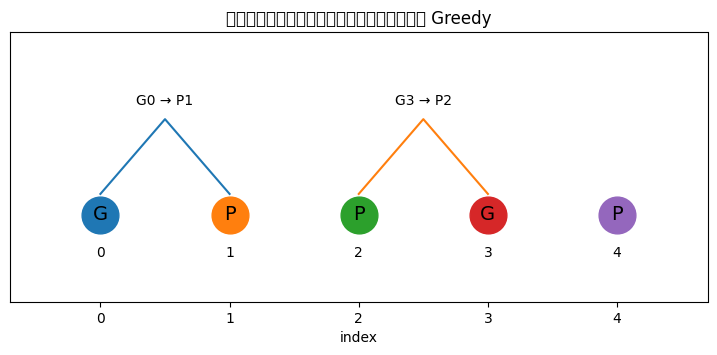

In [ ]:

import matplotlib.pyplot as plt

matches = [(0, 1), (3, 2)]

plt.figure(figsize=(9, 3.5))

for i, ch in enumerate(s):
    plt.scatter(i, 0, s=700)
    plt.text(i, 0, ch, ha="center", va="center", fontsize=14)
    plt.text(i, -0.22, str(i), ha="center", va="center", fontsize=10)

for g_pos, p_pos in matches:
    mid = (g_pos + p_pos) / 2
    height = 0.55
    plt.plot([g_pos, mid, p_pos], [0.12, height, 0.12])
    plt.text(mid, height + 0.08, f"G{g_pos} → P{p_pos}", ha="center", fontsize=10)

plt.xlim(-0.7, len(s)-0.3)
plt.ylim(-0.5, 1.05)
plt.yticks([])
plt.xlabel("index")
plt.title("ตัวอย่างการจับคู่แบบ Greedy")
plt.show()



## Q2.6 โค้ด Greedy จริง

ตอนส่งงานเราไม่ต้องพิมพ์รายละเอียดแต่ละรอบ  
เหลือเพียง loop สั้น ๆ นี้


In [ ]:

g = 0
p = 0
count = 0

while g < len(grabs) and p < len(passengers):

    if abs(grabs[g] - passengers[p]) <= k:
        count += 1
        g += 1
        p += 1

    elif grabs[g] < passengers[p]:
        g += 1

    else:
        p += 1

print(count)


2



# Q2 — เวอร์ชันสำหรับส่งงาน

```python
s = input().strip()
k = int(input())

grabs = []
passengers = []

for i in range(len(s)):
    if s[i] == 'G':
        grabs.append(i)
    elif s[i] == 'P':
        passengers.append(i)

g = 0
p = 0
count = 0

while g < len(grabs) and p < len(passengers):

    if abs(grabs[g] - passengers[p]) <= k:
        count += 1
        g += 1
        p += 1

    elif grabs[g] < passengers[p]:
        g += 1

    else:
        p += 1

print(count)
```



# เปรียบเทียบ Q1 กับ Q2

| เรื่อง | Q1 Brute Force | Q2 Greedy |
|---|---|---|
| วิธีคิด | ลองทุกทางเลือก | เลือกจากซ้ายไปขวา |
| เทคนิค | Recursion + Backtracking | Two Pointers |
| ตัวแปรสำคัญ | `used`, `index`, `count` | `g`, `p`, `count` |
| นับจำนวน solution | ✅ | ❌ |
| หาจำนวน Passenger สูงสุด | ✅ | ✅ |
| ความเร็ว | ช้ากว่า | เร็วกว่า |

## จำสั้น ๆ

### Q1
```text
เลือก -> ลอง -> ย้อนกลับ
```

### Q2
```text
เทียบ G กับ P -> จับได้ก็ใช้ -> จับไม่ได้ก็ข้ามฝั่งที่อยู่ซ้ายเกินไป
```



# แบบฝึกหัดจากไฟล์ที่ให้มา

ลองเปลี่ยนค่า `s` และ `k` ด้านบนเป็นชุดเหล่านี้ แล้วรันใหม่

### ชุดที่ 1
```python
s = "GPGPGPGPGPGPGPGPGPGP"
k = 2
```

### ชุดที่ 2
```python
s = "GGPPGGGGPPPG"
k = 3
```

แนะนำให้ลองตามลำดับ:

1. ดู `grabs` และ `passengers`
2. ดูภาพตำแหน่ง
3. รัน Q1
4. รัน Q2
5. เปรียบเทียบว่า **จำนวน Passenger สูงสุดตรงกันหรือไม่**
